# 项目：分析鸢尾花种类数据

## 分析目标

此数据分析报告的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异，让我们可以对不同种类鸢尾花的属性特征进行推断。

## 简介

原始数据`Iris.csv`包括两种鸢尾花，每种有 50 个样本，以及每个样本的一些属性，包括萼片的长度和宽度、花瓣的长度和宽度。

`Iris.csv`每列的含义如下：
- Id：样本的ID。
- SepalLengthCm：萼片的长度（单位为厘米）。
- SepalWidthCm：萼片的宽度（单位为厘米）。
- PetalLengthCm：花瓣的长度（单位为厘米）。
- PetalWidthCm：花瓣的宽度（单位为厘米）。
- Species：鸢尾花种类。

## 引入库和函数及导入原始数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

读取原始数据Iris.csv，并将原始数据赋值给iris_original。

In [2]:
original_iris = pd.read_csv("Iris.csv")
original_iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor


## 数据评估和清洗

评估数据主要分为两个方向：数据整洁度和干净度。  
整洁度的标准是“每行只有一个观察值，每列只有一个变量，每个单元格只有一个值。  
数据干净度主要判断有无空缺数据，重复数据，不一致数据，无效和错误数据等。

为了将原始数据和清洗过的数据区分开来，我们将创建新的变量cleaned_iris并作为原始数据original_iris复制的副本，之后所有的清洗步骤都在cleaned_iris上使用。

In [3]:
cleaned_iris = original_iris.copy()
cleaned_iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor


### 评估整洁度

由于cleaned_iris数据符合“每行一个观察值，每列一个变量，每个单元格是一个值”的标准，因此数据cleaned_iris是整洁数据。

### 评估干净度

#### 处理缺失数据

首先使用info方法对cleaned_iris数据有个大致的了解。

In [4]:
cleaned_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


由此可知，cleaned_iris数据一共有100行，各列非缺失值数量均为100，因此各变量不存在缺失值。经观察id列现实数据类型是整数，应该改为字符串，需要进行数据类型转换。

In [5]:
cleaned_iris['Id'] = cleaned_iris['Id'].astype('str')
cleaned_iris['Id']

0       1
1       2
2       3
3       4
4       5
     ... 
95     96
96     97
97     98
98     99
99    100
Name: Id, Length: 100, dtype: object

#### 处理重复数据

根据cleaned_iris各变量的意义可知，Id列代表每个鸢尾花样本的唯一标识，不能有重复数据，因此需要检查Id列是否有重复数据。

In [6]:
cleaned_iris['Id'].duplicated().sum()

0

重复值数量和为0，因此Id列不存在重复数据。

#### 处理不一致数据

根据cleaned_iris各变量的意义可知，不一致数据可能存在于Species列中，即有可能出现不同描述指代同一鸢尾花种类。

使用value_counts方法检查Species列中各变量的种类和数量。

In [7]:
cleaned_iris['Species'].value_counts()

Iris-setosa        50
Iris-versicolor    50
Name: Species, dtype: int64

经验证，Species列只包含两种描述，都指代不同鸢尾花的种类，不存在不一致数据。为了节省空间，我们可以把Species列的字符串数据类型转化成category类型。

In [8]:
cleaned_iris['Species'] = cleaned_iris['Species'].astype('category')
cleaned_iris['Species']

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
           ...       
95    Iris-versicolor
96    Iris-versicolor
97    Iris-versicolor
98    Iris-versicolor
99    Iris-versicolor
Name: Species, Length: 100, dtype: category
Categories (2, object): ['Iris-setosa', 'Iris-versicolor']

#### 处理无效和错误数据

使用describe方法对cleaned_iris的数值变量进行统计学描述。

In [9]:
cleaned_iris.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.094000,2.862000,0.785000
std,0.641698,0.476057,1.448565,0.566288
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


以上可知，cleaned_iris里不存在脱离现实意义的数值。

## 数据整理

数据整理与分析方向密切相关，此次数据分析的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异。  
因此可以根据Species列筛选出各个鸢尾花种类的样本数据。

In [10]:
iris_setosa = cleaned_iris.query('Species == "Iris-setosa"')
iris_setosa

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [11]:
len(iris_setosa)

50

In [12]:
iris_versicolor = cleaned_iris.query('Species == "Iris-versicolor"')
iris_versicolor

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
55,56,5.7,2.8,4.5,1.3,Iris-versicolor
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
57,58,4.9,2.4,3.3,1.0,Iris-versicolor
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
59,60,5.2,2.7,3.9,1.4,Iris-versicolor


## 探索数据

在做推断统计学分析之前，我们可以用数据可视化对两种鸢尾花变量特点进行探索。  
数据可视化可以帮我们更直观的了解数据，查看数据分布及变量之间的关系，从而为后续的分析提供方向。  
对于数值变量可以使用成对图，通过密度图可以查看不同变量数值的分布情况，通过散点图可以了解变量之间的关系。  
另外由于本次分析的目的是推断不同种类的鸢尾花属性参数是否存在显著差异，因此可以使用颜色对不同种类的鸢尾花样本分类。

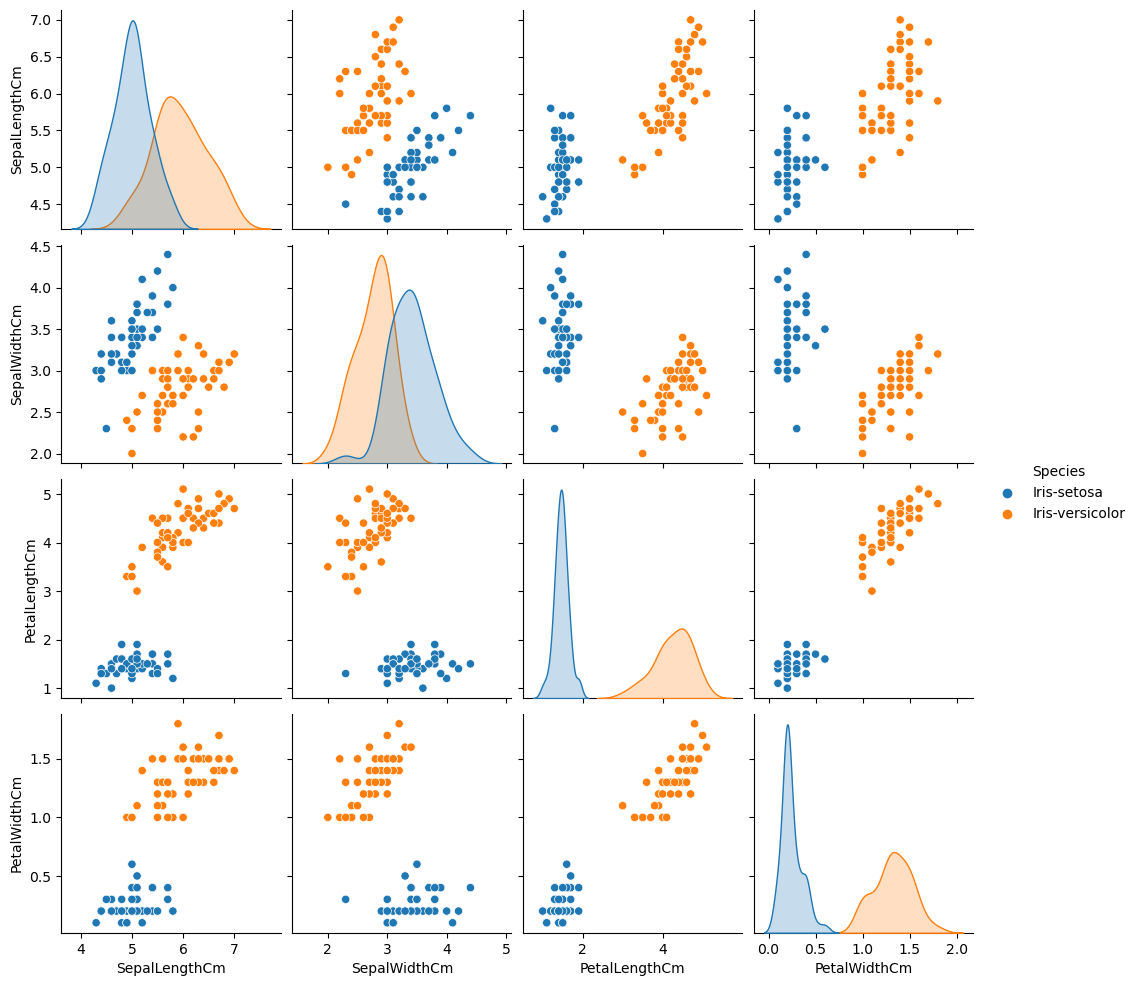

In [13]:
sns.pairplot(cleaned_iris, hue = 'Species')
plt.show()

通过密度图观察各个变量数值的分布可知，Setosa和Versicolor的花瓣长度和宽度数值分布明显不同，可以猜测假设检验的结果是：Setosa和Versicolor两种鸢尾花的花瓣长度和宽度平均值有显著差异。  
而Setosa和Versicolor样本的萼片长度和宽度在密度图上有重叠部分，不能通过图表下结论，需要假设检验来验证两种鸢尾花的萼片长度和宽度是否存在显著差异。

## 分析数据

我们将利用假设检验来以此验证Setosa和Versicolor两种鸢尾花总体萼片、花瓣的长度、宽度平均值是否存在显著差异。  
由于已知的样本数据量不大，且不知道总体的方差，因此将使用独立双样本t检验来推断。假设此数据样集本符合t检验的前提：样本为随机抽样，且总体数值呈正态分布。

引入t检验模块

In [14]:
from scipy.stats import ttest_ind

### 分析萼片长度

首先使用可视化查看Setosa和Versicolor样本的萼片长度分布。

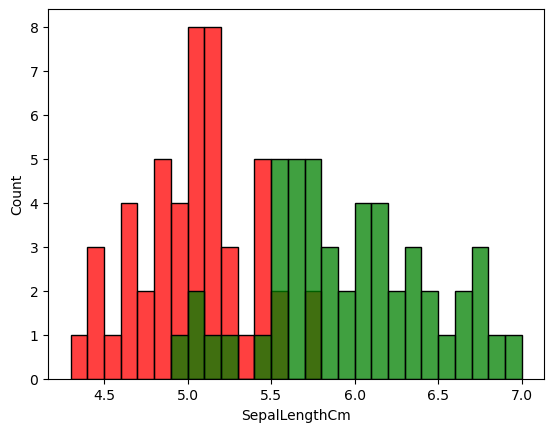

In [29]:
sns.histplot(iris_setosa, x = 'SepalLengthCm', binwidth = 0.1, color = 'red')
sns.histplot(iris_versicolor, x = 'SepalLengthCm', binwidth = 0.1, color = 'green')
plt.show()

#### 建立假设

$H_0$：Setosa和Versicolor两种鸢尾花的萼片长度平均值没有显著差异。  
    
$H_1$：Setosa和Versicolor两种鸢尾花的萼片长度平均值有显著差异。  

#### 确认单尾或双尾检验

由于只是检验总体平均值有无显著差异，因此本次检验是双尾检验。

#### 确认显著水平

选择0.05作为显著水平。

#### 计算t值和p值

In [16]:
t_stat, p_value = ttest_ind(iris_setosa['SepalLengthCm'], iris_versicolor['SepalLengthCm'])
print(f't值为{t_stat}，p值为{p_value}')

t值为-10.52098626754911，p值为8.985235037487079e-18


#### 将p值与显著水平比较

In [17]:
#将显著水平的值赋值给变量alpha
alpha = 0.05
#比较p值和alpha，并比较结果打印t假设验证结果
if p_value < alpha:
    print('Setosa和Versicolor两种鸢尾花的萼片长度平均值有显著差异')
else:
    print('Setosa和Versicolor两种鸢尾花的萼片长度平均值没有显著差异')

Setosa和Versicolor两种鸢尾花的萼片长度平均值有显著差异


#### 结论

p值小于显著水平0.05，因此拒绝原假设，结论为Setosa和Versicolor两种鸢尾花的萼片长度平均值有显著性差异。

### 分析萼片宽度

使用可视化查看Setosa和Versicolor两种鸢尾花样本的萼片宽度的数值分布。

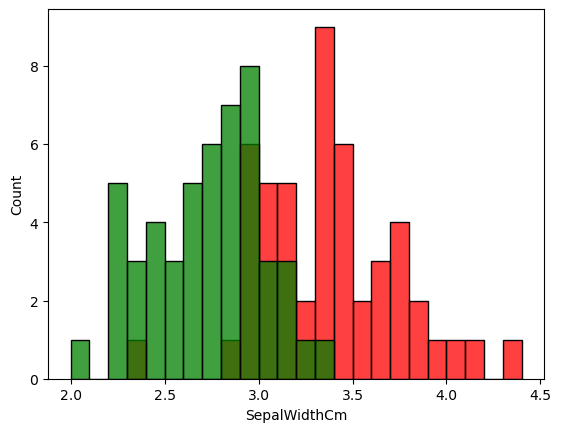

In [28]:
sns.histplot(iris_setosa['SepalWidthCm'], binwidth = 0.1, color = 'red')
sns.histplot(iris_versicolor['SepalWidthCm'], binwidth = 0.1, color = 'green')
plt.show()

#### 建立假设

$H_0$：Setosa和Versicolor两种鸢尾花萼片宽度总体平均值没有显著性差异。

$H_1$：Setosa和Versicolor两种鸢尾花萼片宽度总体平均值有显著性差异。

#### 确认检验是单尾还是双尾

由于只是检验总体参数有无显著性差异，不需要验证那种鸢尾花萼片宽度更大，因此是双尾检验。

#### 确认显著水平

选择0.05作为显著水平。

#### 计算t值和p值

In [19]:
t_stat, p_value = ttest_ind(iris_setosa['SepalWidthCm'], iris_versicolor['SepalWidthCm'])
print(f't值：{t_stat}')
print(f'p值：{p_value}')

t值：9.282772555558111
p值：4.362239016010214e-15


#### 比较p值和显著水平

In [20]:
#将显著水平的值赋值给变量alpha
alpha = 0.05
#比较p值和alpha，并比较结果打印t假设验证结果
if p_value < alpha:
    print('Setosa和Versicolor两种鸢尾花的萼片宽度平均值有显著性差异')
else:
    print('Setosa和Versicolor两种鸢尾花的萼片长度平均值没有显著性差异')

Setosa和Versicolor两种鸢尾花的萼片宽度平均值有显著性差异


#### 结论

p值小于显著水平，因此拒绝原假设，结论为Setosa和Versicolor两种鸢尾花的萼片宽度平均值有显著性差异。

### 分析花瓣长度

首先使用可视化来查看Setosa和Versicolor样本的花瓣长度数值分布情况。

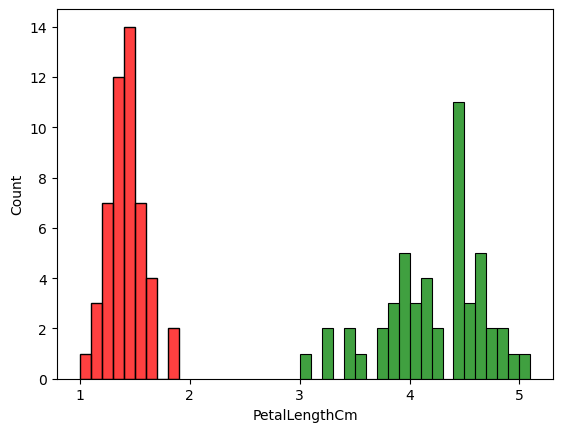

In [27]:
sns.histplot(iris_setosa['PetalLengthCm'], binwidth = 0.1, color = 'red')
sns.histplot(iris_versicolor['PetalLengthCm'], binwidth = 0.1, color = 'green')
plt.show()

#### 建立假设

$H_0$：Setosa和Versicolor两种鸢尾花总体的花瓣长度的平均值没有显著性差异。

$H_1$：Setosa和Versicolor两种鸢尾花总体的花瓣长度的平均值有显著性差异。

#### 确认检验是单尾还是双尾

由于只需要检验总体平均值有无显著性差异，不需要验证哪种花的花瓣更长，因此是双尾检验。

#### 确认显著水平

选择0.05作为显著水平。

#### 计算t值和p值

In [22]:
t_stat, p_value = ttest_ind(iris_setosa['PetalLengthCm'], iris_versicolor['PetalLengthCm'])
print(f't值为：{t_stat}')
print(f'p值为：{p_value}')

t值为：-39.46866259397272
p值为：5.717463758170621e-62


#### 比较p值和显著水平

In [23]:
#将显著水平的值赋值给变量alpha
alpha = 0.05
#比较p值和alpha，并比较结果打印t假设验证结果
if p_value < alpha:
    print('Setosa和Versicolor两种鸢尾花的花瓣长度平均值有显著性差异')
else:
    print('Setosa和Versicolor两种鸢尾花的花瓣长度平均值没有显著性差异')

Setosa和Versicolor两种鸢尾花的花瓣长度平均值有显著性差异


#### 结论

由于p值小于显著水平，因此拒绝原假设，结论是Setosa和Versicolor两种鸢尾花的花瓣长度平均值有显著性差异。

### 分析花瓣宽度

先使用可视化查看Setosa和Versicolor两种鸢尾花样本的花瓣宽度数值分布

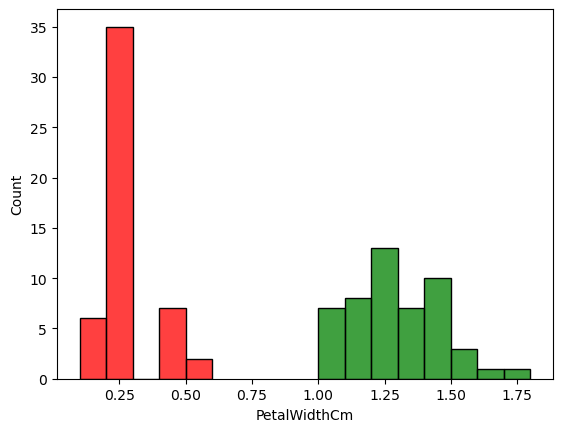

In [24]:
sns.histplot(iris_setosa['PetalWidthCm'], binwidth = 0.1, color = 'red')
sns.histplot(iris_versicolor['PetalWidthCm'], binwidth = 0.1, color = 'green')
plt.show()

#### 建立假设

$H_0$：Setosa和Versicolor两种鸢尾花总体的花瓣宽度平均值没有显著性差异。

$H_1$：Setosa和Versicolor两种鸢尾花总体的花瓣宽度平均值有显著性差异。

#### 确认检验是单尾还是双尾

由于只是检验总体平均值有无显著性差异，不需要检验哪种鸢尾花的花瓣更宽，因此是双尾检验。

#### 确认显著水平

选择显著水平为0.05

#### 计算t值和p值

In [25]:
t_stat, p_value = ttest_ind(iris_setosa['PetalWidthCm'], iris_versicolor['PetalWidthCm'])
print(f't值为：{t_stat}')
print(f'p值为：{p_value}')

t值为：-34.01237858829048
p值为：4.589080615710866e-56


#### 比较p值和显著水平

In [26]:
#将显著水平的值赋值给变量alpha
alpha = 0.05
#比较p值和alpha，并比较结果打印t假设验证结果
if p_value < alpha:
    print('Setosa和Versicolor两种鸢尾花的花瓣宽度平均值有显著性差异')
else:
    print('Setosa和Versicolor两种鸢尾花的花瓣宽度平均值没有显著性差异')

Setosa和Versicolor两种鸢尾花的花瓣宽度平均值有显著性差异


#### 结论

由于p值小于显著水平，因此拒绝原假设，结论是Setosa和Versicolor两种鸢尾花总体的花瓣宽度平均值有显著性差异。

#### 结论

经过前面的推论统计学计算，我们可以得知，Setosa和Versicolor两种鸢尾花总体萼片、花瓣从长度和宽度的平均值均存在显著性差异。